# Approximation (curve fitting)

## Introduction

In engineering practice we often encounter a table of data that may be affected by measurement or numerical errors.

Let us look at an example of measuring a (linear) spring ($x$ is the displacement, $y$ is the measured force):

In [1]:
import numpy as np

x = np.array([0.1,  1.1, 2.05, 3.2, 3.9  ])
y = np.array([0.22, 18.15, 44.33, 75.59, 105.63])

Let us look at the data in a figure; first we import the required packages:

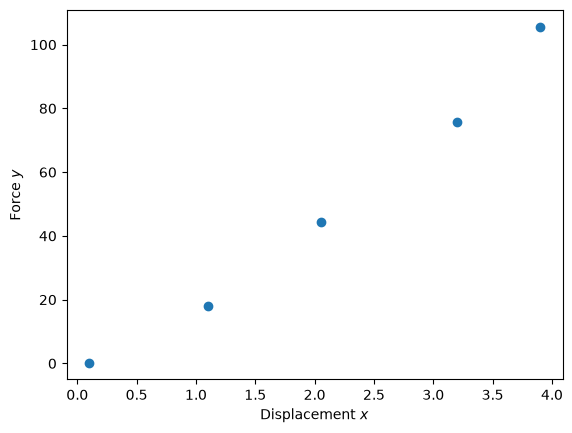

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(x, y, 'o');
plt.xlabel('Displacement $x$')
plt.ylabel('Force $y$');

For this particular example, given our knowledge of the physical background of a linear spring, it would be appropriate to try to describe the measurements with a linear function:

$$f(x) = a_0\,x+ a_1$$

We know a table of $n$ data points $x_i, y_i$ for $i=0,1,\dots,n-1$; there are more of them than we need to determine the two constants $a_0$ and $a_1$, so we have an overdetermined system of linear equations:

$$y_i=a_0\,x_i+a_1\quad\textrm{za}\quad i=0,1,\dots,n-1.$$

We are looking for values of the constants $a_0$ and $a_1$ such that the function $f(x)$ *best* matches $y_i$ at the known points $x_i$.

So first we need a criterion for the *best* match.

For the values $x_i, y_i$ from the table we could look for values of $a_0$ and $a_1$ at which the sum of the absolute values of the deviations $P$ is the smallest:

$$P(a_0, a_1) = \sum_{i=0}^{n-1} |y_i - (a_0\,x_i+a_1)|.$$

However, since such a function $P(a_0, a_1)$ is not continuously differentiable, we prefer to use the **least-squares method**:

$$S(a_0, a_1) = \sum_{i=0}^{n-1} \left(y_i - (a_0\,x_i+a_1)\right)^2.$$

Such a function $S(a_0, a_1)$ is continuous and continuously differentiable. By taking partial derivatives with respect to the parameters $a_0$ and $a_1$ we can find a stationary point (the partial derivatives are equal to 0). We will go through the procedure for a linear function in the next section.

## Least-squares method for a linear function

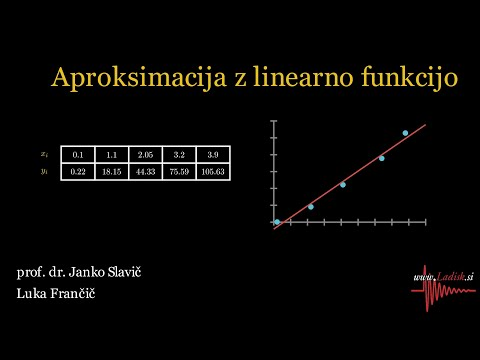

In [3]:
from IPython.display import YouTubeVideo
YouTubeVideo('8-oixY6GG9E', width=800, height=300)

We need to find the constants $a_0$, $a_1$ such that the sum of the squares of the differences between the function and the tabulated value ($x_i, y_i$, where $i=0,1,\dots, n-1$ and $n$ is the number of tabulated data points):

$$S(a_0, a_1) = \sum_{i=0}^{n-1} \left(y_i - (a_0\,x_i+a_1)\right)^2$$

is the smallest. The value will be smallest at the stationary point, which we determine by taking the partial derivative with respect to the parameters $a_0$ and $a_1$.

First we take the partial derivative with respect to the parameter $a_0$:

$$\frac{\partial S(a_0, a_1)}{\partial a_0} = 2\,\sum_{i=0}^{n-1} \left(y_i - a_0\,x_i-a_1\right)\,(-x_i)$$

We rearrange the expression:

$$\frac{\partial S(a_0, a_1)}{\partial a_0} =-2\left(\sum_{i=0}^{n-1} y_i\,x_i -a_0\,\sum_{i=0}^{n-1} x_i^2- a_1\,\sum_{i=0}^{n-1} x_i\right)$$

We proceed similarly for $a_1$:

$$\frac{\partial S(a_0, a_1)}{\partial a_1} = 2\,\sum_{i=0}^{n-1} \left(y_i  - a_0\,x_i- a_1\right)\,(-1)$$

$$\frac{\partial S(a_0, a_1)}{\partial a_1} = -2\left(\sum_{i=0}^{n-1} y_i -a_0\,\sum_{i=0}^{n-1} x_i- a_1\,\sum_{i=0}^{n-1}1\right)$$

Since at the stationary point $\partial S(a_0, a_1)/\partial a_0=0$ and $\partial S(a_0, a_1)/\partial a_1=0$, from the expressions above we derive:

$$a_0\,\sum_{i=0}^{n-1} x_i^2 + a_1\,\sum_{i=0}^{n-1} x_i=\sum_{i=0}^{n-1} y_i\,x_i$$

and

$$a_0\,\sum_{i=0}^{n-1} x_i+ a_1\,n=\sum_{i=0}^{n-1} y_i.$$

We have obtained a system of two linear equations for the unknowns $a_0$ and $a_1$, which we know how to solve. We call it the *normal system* (the number of equations equals the number of unknowns).

Let us write the normal system in matrix form:

In [4]:
A = [[np.sum(x**2), np.sum(x)], # coefficient matrix
     [np.sum(x), len(x)]]
b = [np.dot(y,x), np.sum(y)]    # vector of constants
A = np.asarray(A)
b = np.asarray(b)
print('A:', A)
print('b:', b)

A: [[30.8725 10.35  ]
 [10.35    5.    ]]
b: [764.7085 243.92  ]


Now we need to solve the linear system:

$$\mathbf{A}\,\mathbf{a}=\mathbf{b},$$

Note: here we have written the vector of unknowns as $\mathbf{a}=(a_0, a_1)$.

We solve the system:

In [5]:
a0, a1 = np.linalg.solve(A, b)
a0, a1

(np.float64(27.497258679085512), np.float64(-8.135325465707014))

Let us also check the condition number:

In [6]:
np.linalg.cond(A)

np.float64(25.20071350870242)

Now we will look at the result. First we prepare a figure that will also contain information about the sum of squares of the deviation of $f(x_i)$ from the tabulated values $y_i$.

In [7]:
def figure(slope=a0, shift=a1):
    d=1
    def linear_f(x, a0, a1):
        return a0*x+a1
    def S(x, y, f):
        return np.sum(np.power(y-f,2))
    plt.plot(x,y,'.', label='Data table')
    linear_f1 = linear_f(x, slope, shift)
    linear_f1_LS = linear_f(x, a0, a1)
    plt.plot(x, linear_f1, '-', label='Selected parameters')
    plt.plot(x, linear_f1_LS, '-', label='Least-squares method')
    error = S(x, y, linear_f(x, slope, shift))
    error_change_in_a0_direction = (S(x, y, linear_f(x, slope+d, shift))-error)/d
    error_change_in_a1_direction = (S(x, y, linear_f(x, slope, shift+d))-error)/d
    title = f'S: {error:g}, \
            $\\Delta S/\\Delta a_0$: {error_change_in_a0_direction:g}, \
            $\\Delta S/\\Delta a_1$: {error_change_in_a1_direction:g}'
    plt.title(title)
    plt.legend()
    plt.ylim(-10,110)
    plt.show()

In [8]:
from ipywidgets import interact
interact(figure, slope=(0, 50, 2), shift=(-10, 10, 1));

interactive(children=(IntSlider(value=27, description='slope', max=50, step=2), IntSlider(value=-8, descriptio…

### Using the pseudo-inverse matrix

We can reach the same result using the pseudo-inverse matrix. We look for $y(x)=a_0\,x+a_1$ and set up the overdetermined system $\mathbf{A}\,\mathbf{a}=\mathbf{y}$, where the coefficient matrix $\mathbf{A}$ is defined according to the values $x_i$ ($i=0,1,\dots,n-1$):

In [9]:
A=np.array([x, np.ones_like(x)]).T
A

array([[0.1 , 1.  ],
       [1.1 , 1.  ],
       [2.05, 1.  ],
       [3.2 , 1.  ],
       [3.9 , 1.  ]])

We have denoted the vector of constants by $\mathbf{b}$, but in our case this is simply the vector of values $\mathbf{y}$ with elements $y_i$ ($i=0,1,2,\dots,n-1$):

In [10]:
y

array([  0.22,  18.15,  44.33,  75.59, 105.63])

Let us check the rank of the coefficient matrix:

In [11]:
np.linalg.matrix_rank(A)

np.int64(2)

And also the rank of the augmented matrix:

In [12]:
Ab = np.hstack((A,np.array([y]).T))
Ab

array([[1.0000e-01, 1.0000e+00, 2.2000e-01],
       [1.1000e+00, 1.0000e+00, 1.8150e+01],
       [2.0500e+00, 1.0000e+00, 4.4330e+01],
       [3.2000e+00, 1.0000e+00, 7.5590e+01],
       [3.9000e+00, 1.0000e+00, 1.0563e+02]])

In [13]:
np.linalg.matrix_rank(Ab)

np.int64(3)

Since we are solving a system of $m$ linear equations with $n$ unknowns, and $m>n$ holds and the rank of the augmented matrix is $n+1$, we have an overdetermined system.

We determine the vector of unknown parameters $\mathbf{a}$ using the pseudo-inverse matrix:

$$\mathbf{a}=\mathbf{A}^{+}\,\mathbf{y}$$

In [14]:
np.linalg.pinv(A).dot(y)

array([27.49725868, -8.13532547])

## Least-squares method for an arbitrary polynomial

We will generalize the linear approximation presented above to an arbitrary polynomial of degree $m$:

$$f(a_0,a_1,\dots,a_{m}, x) = \sum_{s=0}^{m}a_s\,\underbrace{x^{m-s}}_{f_s(x)},$$

where $f_s(x)=x^{m-s}$ is called a basis function ($s=0,1,2,\dots,m$).

Let the data table be defined by $x_i, y_i$, where $i=0,1,2,\dots,n-1$.

Note: for compactness of notation we will write the constants $a$ in vector form $\mathbf{a}=[a_0, a_1,\dots,a_m]$.

We use the least-squares method:

$$S(\mathbf{a}) = \sum_{i=0}^{n-1} \left(y_i - f(\mathbf{a}, x_i)\right)^2= \sum_{i=0}^{n-1} \left(y_i - \sum_{s=0}^{m}a_s\,x_i^{m-s}\right)^2.$$

The necessary condition for an extremum of a function of $m+1$ independent variables is that we find a stationary point for each $a_v$, so we look for $\partial S(\mathbf{a})/\partial a_v=0$ (instead of $s$ we have used the index $v$).

First we determine the partial derivative for the chosen $a_v$:

$$\frac{\partial S(\mathbf{a})}{\partial a_v} = \sum_{i=0}^{n-1} - 2\,\left(y_i - \sum_{s=0}^{m}a_s\,x_i^{m-s}\right)\,x_i^{m-v}$$

Note: $\frac{\partial}{\partial a_v}\left(\sum_{s=0}^{m}a_s\,x_i^{m-s}\right)=x_i^{m-v}$.

Since the partial derivative at the stationary point is equal to 0, we rearrange the expression above:

$$\sum_{i=0}^{n-1} \left(\sum_{s=0}^{m}a_s\,x_i^{m-s}\right)\,x_i^{m-v}=\sum_{i=0}^{n-1} y_i\,x_i^{m-v}$$

We rearrange the expression:

$$\sum_{i=0}^{n-1} \sum_{s=0}^m a_s\,x_i^{2m-s-v}=\sum_{i=0}^{n-1} y_i\,x_i^{m-v}$$

We swap the order of summation and derive:

$$\sum_{s=0}^m \left(a_s \sum_{i=0}^{n-1} \,x_i^{2m-s-v}\right)=\sum_{i=0}^{n-1} y_i\,x_i^{m-v}\quad\textrm{za:}\quad v=0,1,\dots,m$$

We have derived equation $v$ of the system of $m+1$ linear equations:

$$\mathbf{A}\,{\mathbf{a}}=\mathbf{b}$$

The element $A_{v,s}$ of the coefficient matrix is:

$$A_{v,s}= \sum_{i=0}^{n-1} x_i^{2m-v-s},$$

The element of the vector of constants is:

$$b_{v}= \sum_{i=0}^{n-1} y_i\,x_i^{m-v}$$

### Numerical example

Let us use the data from the first problem and try to approximate it with a 2nd-degree polynomial ($m=2$).

The data table is:

In [15]:
x

array([0.1 , 1.1 , 2.05, 3.2 , 3.9 ])

In [16]:
y

array([  0.22,  18.15,  44.33,  75.59, 105.63])

Let us compute the coefficient matrix:

$$A_{v,s}= \sum_{i=0}^{n-1} x_i^{2m-v-s}$$

In [17]:
m = 2 #degree
A = np.zeros((m+1,m+1))
for v in range(m+1):
    for s in range(m+1):
        A[v,s] = np.sum(x**(2*m-v-s))
A

array([[355.32690625, 102.034125  ,  30.8725    ],
       [102.034125  ,  30.8725    ,  10.35      ],
       [ 30.8725    ,  10.35      ,   5.        ]])

Let us also compute the vector of constants:

$$b_{v}= \sum_{i=0}^{n-1} y_i\,x_i^{m-v}$$

In [18]:
b = np.zeros(m+1)
for v in range(m+1):
    b[v] = np.dot(y,x**(m-v))
b

array([2588.934425,  764.7085  ,  243.92    ])

Let us check the condition number:

In [19]:
np.linalg.cond(A)

np.float64(963.2125856290679)

We solve the system:

In [20]:
a = np.linalg.solve(A, b)
a

array([ 3.17760897, 14.67380042, -1.21091344])

Given the definition of the approximating polynomial:

$$f(a_0,a_1,\dots,a_{m}, x) = \sum_{v=0}^{m}a_v\,x^{m-v}$$

which in this particular case is the approximating polynomial:

$$f(x)=3.18393375\,x^2 + 14.64106847\,x -1.22621065$$

Let us define a numerical implementation:

In [21]:
def apr_polynomial(x, a):
    """Returns the values of the approximating polynomial

    :param x: values at which we compute the approximated result
    :param a: coefficients of the approximating polynomial
    """
    m = len(a) - 1
    return np.sum(np.asarray([_*x**(m-v) for v,_ in enumerate(a)]), axis=0)

We plot:

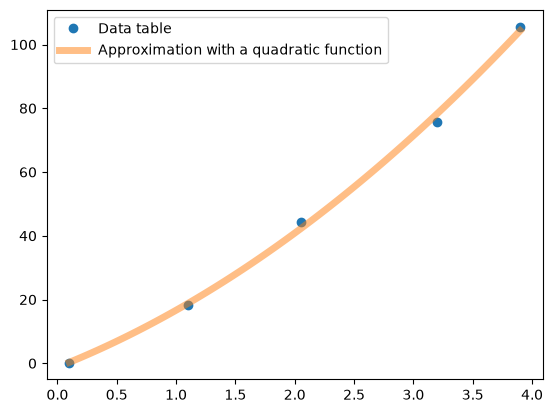

In [22]:
x_g = np.linspace(np.min(x), np.max(x), 100) # more points for plotting
plt.plot(x, y, 'o', label='Data table')
plt.plot(x_g, apr_polynomial(x_g, a), lw=5, alpha=0.5, label='Approximation with a quadratic function')
plt.legend();

Let us also look at the approximation error:

$$e_i=y_i - f(x_i)$$

for $i=0,1,2,\dots,n-1$.

With a correctly performed approximation, some $e_i$ are positive and some negative. Let us check whether this is true in our case:

In [23]:
e = y - apr_polynomial(x, a)
e

array([-0.06824269, -0.62517387,  2.1057209 , -2.69396374,  1.28165939])

Note: the higher the degree of the polynomial we use, the greater the probability of poor conditioning. For this reason we do not overdo the polynomial degree (in practice we mainly use low degrees)!

### Using `numpy` for polynomial approximation

Let us look at how to use the `numpy` library for polynomial approximation.

First we use the function `numpy.polyfit` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html)):

```python
polyfit(x, y, deg, rcond=None, full=False, w=None, cov=False)
```

which requires three parameters: `x` and `y` represent the data table (also possible as lists of vectors), and `deg` is the polynomial degree. The remaining parameters are optional (e.g., `w` to use weights in the approximation).

The `polyfit` function returns a list of polynomial coefficients (highest order first); the result can also be a list of lists (if the input data is a list of vectors).

**Note**: `numpy.polyfit` and `numpy.poly1d` belong to the older interface for polynomials; for new programs `numpy` recommends the class `numpy.polynomial.Polynomial` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.polynomial.polynomial.Polynomial.fit.html)): `p = Polynomial.fit(x, y, deg=2)` returns an object that we call as a function (`p(x)`), and `p.convert().coef` gives the coefficients in **increasing** order of powers (exactly the opposite of `polyfit`).

Let us look at its use for the example treated previously:

In [24]:
coef = np.polyfit(x, y, deg=2)
coef

array([ 3.17760897, 14.67380042, -1.21091344])

In [25]:
a # result of our own implementation

array([ 3.17760897, 14.67380042, -1.21091344])

Once we have the coefficients, we can create a polynomial object by calling ``numpy.poly1d`` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.poly1d.html#numpy.poly1d)):

```python
poly1d(c_or_r, r=False, variable=None)
```

where `c_or_r` represents the list of polynomial coefficients, or the roots of the polynomial if `r=True`. The function returns an instance of the object, by calling which we can compute the values of the approximating polynomial at `x`, but we can also compute other things, such as the roots of the polynomial.

Let us look at an example:

In [26]:
p = np.poly1d(coef) # p is an instance of the poly1d object. We now obtain the approximation with y = p(x).

Let us plot the values:

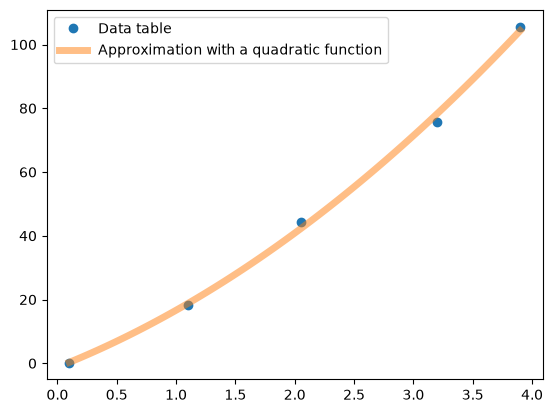

In [27]:
plt.plot(x, y, 'o', label='Data table')
plt.plot(x_g, p(x_g), lw=5, alpha=0.5, label='Approximation with a quadratic function')
plt.legend();

Let us compute the roots of the polynomial:

In [28]:
p.roots

array([-4.69897273,  0.08109792])

## Approximation with an arbitrary function

In approximation we are not limited to polynomials only. We can approximate data tables:

* with a linear combination of linearly independent basis functions, or
* with a function in which the parameters appear in a nonlinear relationship (e.g., $a_0\,\sin(a_1\,x+a_2)$).

For details, see the reference J. Petrišič: Uvod v Matlab za inženirje, Fakulteta za strojništvo 2013, p. 145.

We will focus on using the `scipy` package for approximation with a nonlinear function, which is based on the least-squares method.

### Approximation with a harmonic function

The data table is defined as:

In [29]:
x = np.array([ 0.1, 0.8, 1.7, 2.5, 3.4, 4.2,  5.1])
y = np.array([ 0.01, -1.13, 0.02, 0.92, -0.01, -0.98, 0.1])

Let us plot the data table:

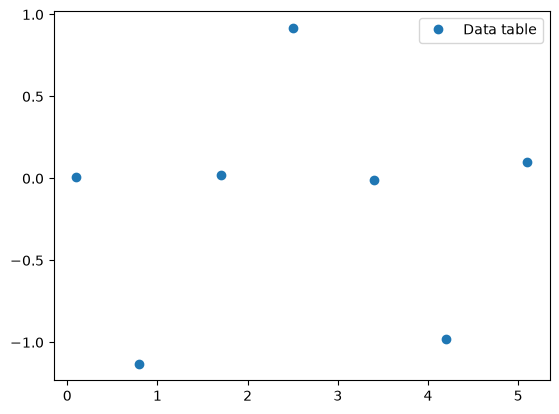

In [30]:
plt.plot(x, y, 'o', label='Data table')
plt.legend();

We will perform the approximation with a nonlinear function using ``scipy.optimize.curve_fit`` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html)):

```python
curve_fit(f, xdata, ydata, p0=None, sigma=None, absolute_sigma=False, check_finite=True, bounds=(-inf, inf), method=None, jac=None, **kwargs)
```


which requires three parameters: `f` represents the definition of the Python function with which we want to approximate, and whose parameters we vary using the least-squares method. `xdata` and `ydata` represent the data table. It is also recommended to define an estimate of the sought parameters `p0`. The remaining parameters are optional.

The function returns two arrays: `popt`, which represents the parameters found, and `pcov`, which represents the estimated covariance of `popt`.

First let us define a Python function whose first parameter is the independent variable `x`, followed by the parameters we want to determine:

In [31]:
def func(x, A, ω, ϕ):
    return A*np.sin(ω*x+ϕ)

where `A` is the amplitude, `ω` the angular frequency, and `ϕ` the phase of the harmonic function. With the help of the figure we can guess the initial estimates: `A=1`, `ω=1`, `ϕ=0`

Now we import `curve_fit` and run the optimization procedure:

In [32]:
from scipy.optimize import curve_fit

In [33]:
popt, pcov = curve_fit(func, x, y, p0=[1, 1, 0])
popt

array([ 1.01461945,  1.89652046, -3.27943097])

We have computed the expected values (see above).

In [34]:
func(x, *popt)

array([-0.0525477 , -0.99608783, -0.05612665,  1.00860622, -0.02753942,
       -1.01426499,  0.1110182 ])

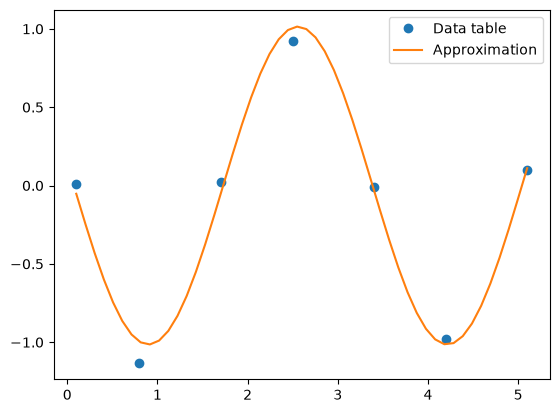

In [35]:
x_g = np.linspace(np.min(x), np.max(x), 50)
y_g = func(x_g, *popt) # note how we passed the parameters to the function
plt.plot(x, y, 'o', label='Data table')
plt.plot(x_g, y_g, label='Approximation')
plt.legend();

# Additional

Make an *.exe* of your program:

* https://pypi.org/project/py2exe/
* http://www.pyinstaller.org/

Take a look at the [pandas package](http://pandas.pydata.org/).
![Pandas](https://pandas.pydata.org/static/img/pandas.svg)

### Approximation with splines using ``SciPy``

Let the data table be:

In [36]:
x = np.linspace(-3, 3, 20)
x

array([-3.        , -2.68421053, -2.36842105, -2.05263158, -1.73684211,
       -1.42105263, -1.10526316, -0.78947368, -0.47368421, -0.15789474,
        0.15789474,  0.47368421,  0.78947368,  1.10526316,  1.42105263,
        1.73684211,  2.05263158,  2.36842105,  2.68421053,  3.        ])

In [37]:
np.random.seed(0) # seed of the random number generator
y = np.exp(-x**2) + 0.1 * np.random.normal(scale=.5, size=len(x))
y

array([ 0.08832603,  0.02075073,  0.0526001 ,  0.12684217,  0.14234432,
        0.08387244,  0.34226064,  0.52862107,  0.79385312,  0.99590738,
        0.98257964,  0.87172774,  0.57424082,  0.30083997,  0.15492949,
        0.06565014,  0.08950146, -0.00659471,  0.01639626, -0.04258138])

Let us look at the object ``scipy.interpolate.UnivariateSpline`` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.UnivariateSpline.html)), which enables both interpolation and approximation with splines:

```python
UnivariateSpline(x, y, w=None, bbox=[None, None], k=3, s=None, ext=0, check_finite=False)
```

The parameters `x` and `y` represent the data table.

**Note**: `UnivariateSpline` has been marked as *legacy* since SciPy 1.15; the more modern equivalent for approximation (smoothing) with splines is `scipy.interpolate.make_smoothing_spline` ([documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.make_smoothing_spline.html)) or `make_splrep`. The object interface below still works and is clearer for learning.

The optional parameter `s` sets the value that the sum of squares of the differences between the approximating spline and the approximation points must not exceed:

```python
sum((w[i] * (y[i]-spl(x[i])))**2, axis=0) <= s
```

`w` are the weights of the individual points.

If we set `s=0`, we require interpolation.

The parameter `k` defines the degree of the polynomial spline (the default is `k=3`).

We perform approximation with splines by defining, in addition to the data table `x` and `y`, the parameter `s` as well. Let us perform interpolation:

In [38]:
from scipy.interpolate import UnivariateSpline
spl = UnivariateSpline(x, y, s=0.)

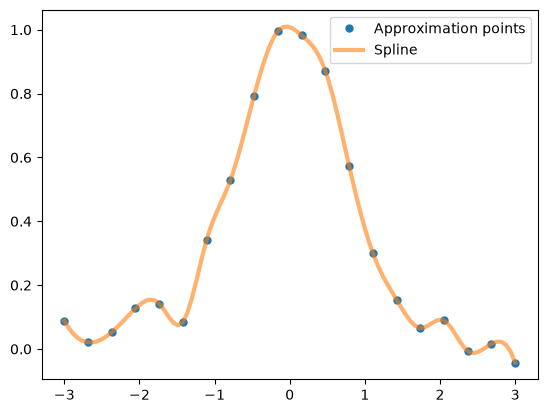

In [39]:
x_g = np.linspace(-3, 3, 100)
plt.plot(x, y, 'o', ms=5, label='Approximation points')
plt.plot(x_g, spl(x_g), lw=3, label='Spline', alpha=0.6)
plt.legend();

Let us also perform the approximation:

In [40]:
spl_a = UnivariateSpline(x, y, s=.1)

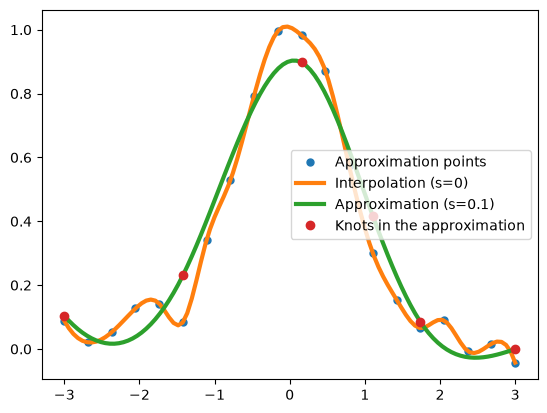

In [41]:
plt.plot(x, y, 'o', ms=5, label='Approximation points')
plt.plot(x_g, spl(x_g), lw=3, label='Interpolation (s=0)');
plt.plot(x_g, spl_a(x_g), lw=3, label='Approximation (s=0.1)');
plt.plot(spl_a.get_knots(), spl_a(spl_a.get_knots()), 'o', label='Knots in the approximation');
plt.legend();

The actual residual:

In [42]:
spl_a.get_residual()

0.10002662427563205

---

# Exercise questions

---

**Question 1:** Rainy weather is coming and you are interested in the coefficient of friction between a car tire and a wet road. In the garage you find a worn-out summer tire, from which you cut out a sample for testing. You attach a force gauge to it, from which you read the force when dragging the tire over wet asphalt. To make your measurement more reliable, you load the tire sample with various weights.

<img src="fig/vaje/trenje.png" style="width:500px">

You know that the relationship between the friction force and the normal force on the surface is linear:

$$F_t = \mu F_n$$

Based on the given measurements you want to determine the value of the friction coefficient $\mu$. Use approximation to help you (you may use any method).

In [43]:
# Data
F_n = np.array([5, 10, 15, 20, 25, 30]) # N
F_t = np.array([ 1.432,  2.365,  3.91 ,  5.166,  6.468,  7.438]) # N

## Least-squares method for a linear function

**Question 2:** For the data from the previous problem, define and solve the system of linear equations to compute the parameters of the linear approximation. Display the result graphically.

**Question 3:** Use the function ``numpy.polyfit`` and approximate the given points ``x, y`` with a polynomial of first, second, third, and fourth order.

In [46]:
# Data, do not delete!
x = np.linspace(0, 5, 100)
y = 0.5*x**4 + 3*x**3 - 20*x**2 + 3*x + 10*np.random.randn(len(x))

**Question 4:** Prepare a function ``errors(y, y_apr)`` that computes and returns the sum of squares of the differences and the standard error (``numpy.std``) for the arrays of given values ``y`` and the approximation result ``y_apr``.

Use it to compare the approximating polynomials of different degrees from the previous problem.

**Question 5:** To determine the drag coefficient $C_D$ of an airplane model, you carry out measurements in a wind tunnel. At various airflow speeds you measure the drag force $F_D$ several times. You know that the dependence of the force $F_D$ on the speed $v$ in your case is given by the equation:

$$F_D = 0.005~C_D \cdot v^2$$

Based on the given values ``v, F_d``, determine the value of the drag coefficient using approximation with a second-degree polynomial.

In [49]:
# Data
v = [6.184, 9.843, 15.582, 20.190, 23.509, 28.890, 34.753, 40.500, 45.979, 50.167]
F_d = [0.029, 0.013, 0.072, 0.054, 0.135, 0.204, 0.300, 0.420, 0.513, 0.643]

**Question 6:** On the same plot, draw the measured points, the result of the polynomial approximation, and the result of the expression

$$F_D = 0.005~C_D \cdot v^2$$

from the previous problem.

Explain why there is a difference between the two plotted curves, how this affects the determination of the coefficient $C_D$, and how you would eliminate this error (hint: print out the obtained coefficients of the approximating polynomial).

**Question 7:** Using the appropriate ``scipy`` function, determine the drag coefficient $C_D$ by approximating the measured points ``v, F_d`` with the function:

$$F_D = 0.005~C_D \cdot v^2$$

Compare the obtained value with the result of the previous problem, display the result graphically, and comment on it.

**Question 8:** In a slow-motion video we observed the deflection of a propeller tip from the horizontal axis at different times. Based on the measurements we want to determine the rotation speed of the propeller.

$$y = \sin(2\pi\cdot f~t + \varphi)$$

where $f$ is the number of propeller revolutions per second.

Determine $f$ by approximating the data with the given function and determining the optimal values of the parameters $f$ and $\varphi$. Observe the effect of the initial estimates ``p0``, which we can optionally pass to the function ``scipy.optimize.curve_fit(fun, x, y, p0)``.

In [53]:
# Data
f = 50
phi = np.pi/4
t = np.linspace(0, 0.01, 100)
y = np.sin(2*np.pi*t*f + phi) + 0.1*np.random.randn(len(t))

## Approximation with splines

**Question 9:** Approximate the given values ``x, y`` with cubic splines using ``scipy.interpolate.UnivariateSpline``.

Plot the approximation curves for three given values of the parameter ``s``. For each one, print the number of spline knots (``spl.get_knots()``) and comment on the result.

In [55]:
# Data
x = np.linspace(-1, 1, 50)
y = 0.5*np.cos(1.7*np.pi*x) + 0.1*np.random.randn(len(x))
s = [0, 0.5, 2]